In [3]:
# --- Personalized Healthcare Recommendations ML Project ---

# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score # For robust evaluation
import xgboost as xgb # For advanced modeling
import lightgbm as lgb # For advanced modeling

# For saving/loading models for deployment
import joblib 

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Load the dataset
file_path = 'blood.csv'
try:
    data = pd.read_csv(file_path)
    print("\nDataset loaded successfully.")
    print(f"Dataset shape: {data.shape}")
except FileNotFoundError:
    print("\nError: 'blood.csv' not found.")
    print("Please ensure your dataset is in the same directory as this script, or update the 'file_path'.")
    exit()

if 'Class' not in data.columns:
    print("\n'Class' column not found. This script requires a 'Class' column as the target.")
    exit() # Exit if target isn't found


Dataset loaded successfully.
Dataset shape: (748, 5)


In [5]:
# --- Initial Data Exploration ---
print("\n--- Initial Data Exploration ---")
print("\nFirst 5 rows of the dataset:")
print(data.head())

print("\nSummary statistics of the dataset:")
print(data.describe())

print("\nDataset information (Dtypes and Non-Null Counts):")
data.info()

print("\nMissing values count:")
print(data.isnull().sum())

print("\nDistribution of 'Class' (target variable):")
print(data['Class'].value_counts())
print(f"Number of unique classes: {data['Class'].nunique()}")


--- Initial Data Exploration ---

First 5 rows of the dataset:
   Recency  Frequency  Monetary  Time  Class
0        2         50     12500    99      1
1        0         13      3250    28      1
2        1         17      4000    36      1
3        2         20      5000    45      1
4        1         24      6000    77      0

Summary statistics of the dataset:
          Recency   Frequency      Monetary        Time       Class
count  748.000000  748.000000    748.000000  748.000000  748.000000
mean     9.506684    5.516043   1378.676471   34.284759    0.237968
std      8.095396    5.841825   1459.826781   24.380307    0.426124
min      0.000000    1.000000    250.000000    2.000000    0.000000
25%      2.750000    2.000000    500.000000   16.000000    0.000000
50%      7.000000    4.000000   1000.000000   28.000000    0.000000
75%     14.000000    7.000000   1750.000000   50.000000    0.000000
max     74.000000   50.000000  12500.000000   99.000000    1.000000

Dataset informati


--- Basic Data Visualization ---


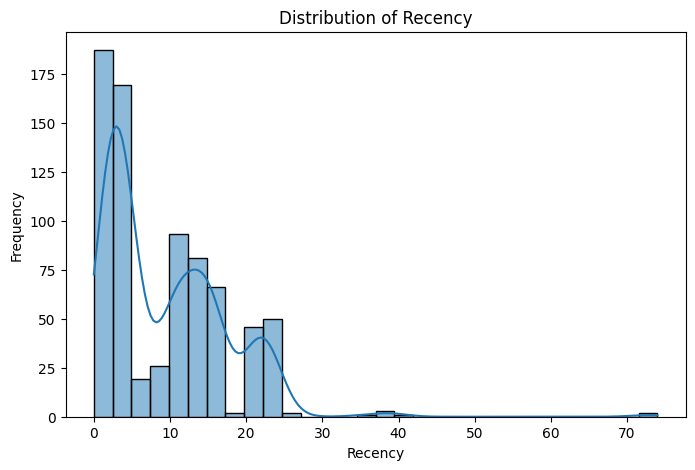

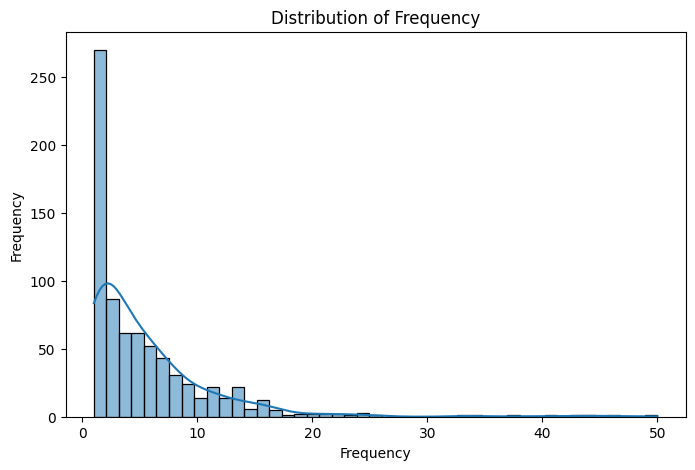

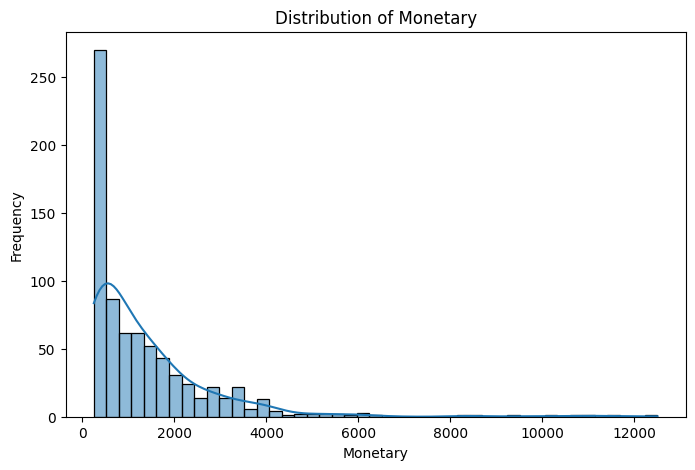

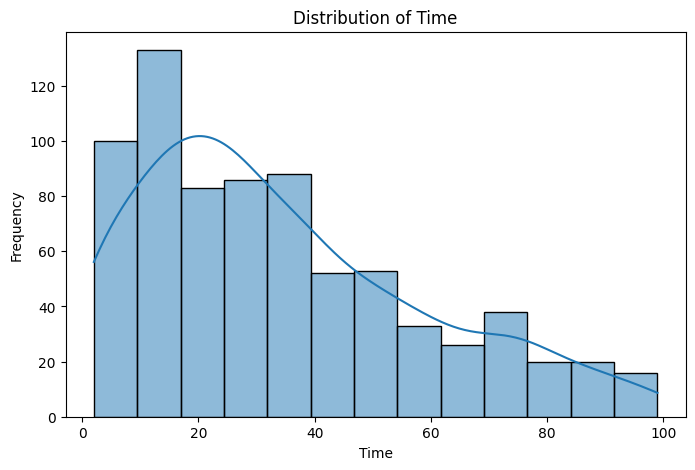

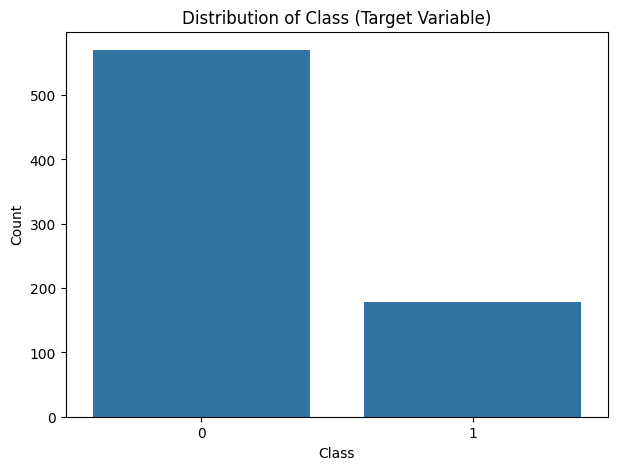

In [6]:
# --- Basic Data Visualization ---
print("\n--- Basic Data Visualization ---")

feature_cols = ['Recency', 'Frequency', 'Monetary', 'Time']

for col in feature_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=data)
plt.title('Distribution of Class (Target Variable)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

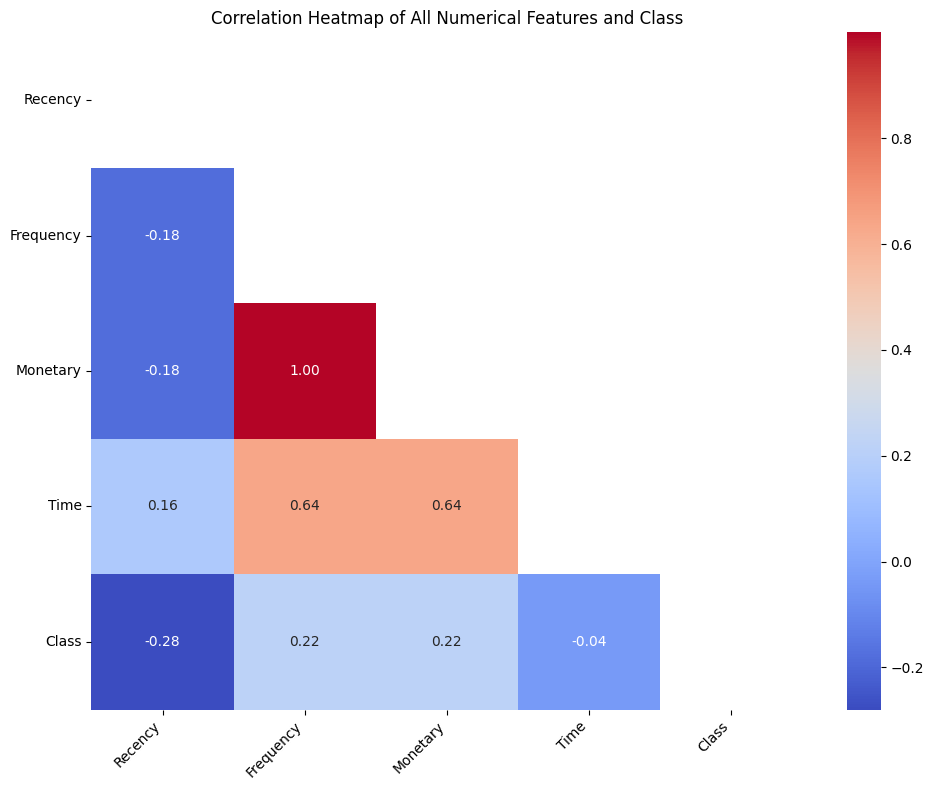


Data exploration and basic visualization complete.


In [7]:
# Correlation Heatmap for all numerical features
df_for_heatmap = data.copy()
numeric_cols = df_for_heatmap.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) > 1:
    corr_matrix = df_for_heatmap[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, cbar=True)
    plt.title('Correlation Heatmap of All Numerical Features and Class')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns to generate a meaningful heatmap.")

print("\nData exploration and basic visualization complete.")

In [8]:
# --- Step 4: Data Preprocessing ---
print("\n--- Step 4: Data Preprocessing ---")

X = data.drop('Class', axis=1)
y = data['Class']

numerical_features = ['Recency', 'Frequency', 'Monetary', 'Time'] 

# Create preprocessing pipelines for numerical features
# Using StandardScaler as previously
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine preprocessors. Since no categorical, only numerical transformer is applied.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ],
    remainder='passthrough' # If any non-numerical features (unlikely here) are present, pass them through
)


--- Step 4: Data Preprocessing ---


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData splitting complete. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

print("\nData Preprocessing (feature identification and pipeline setup) complete.")


# --- Step 5: Feature Engineering ---
print("\n--- Step 5: Feature Engineering ---")

print("No complex feature engineering steps implemented beyond basic data preparation (scaling).")


Data splitting complete. X_train shape: (598, 4), X_test shape: (150, 4)
y_train shape: (598,), y_test shape: (150,)

Data Preprocessing (feature identification and pipeline setup) complete.

--- Step 5: Feature Engineering ---
No complex feature engineering steps implemented beyond basic data preparation (scaling).


In [17]:
# --- Step 6: Model Selection and Training (with Class Weights and new models) ---


positive_class_count = y.value_counts()[1]
negative_class_count = y.value_counts()[0]
scale_pos_weight = negative_class_count / positive_class_count
print(f"\nCalculated scale_pos_weight for imbalance: {scale_pos_weight:.2f}")


# Create the primary model pipeline with RandomForestClassifier (now with class_weight)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced')) # Change this line
])

# Train the primary model pipeline
print("\nTraining the primary model pipeline (RandomForestClassifier with class_weight)...")
model_pipeline.fit(X_train, y_train)
print("Primary model pipeline training complete.")

# --- Evaluate other models with class weights ---
print("\n--- Cross-validating other relevant models (with class weights for imbalance) ---")

# For other classifiers, let's explicitly add class weights
# For XGBoost and LightGBM, `scale_pos_weight` is used directly for binary classification.
# For other scikit-learn models, `class_weight='balanced'`
clf_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf_xgb = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                           scale_pos_weight=scale_pos_weight)
clf_lgb = lgb.LGBMClassifier(random_state=42, class_weight='balanced')

# Cross-validate these models
classifiers_to_cv = [clf_rf, clf_xgb, clf_lgb]
labels_to_cv = ["RandomForest (Balanced)", "XGBoost (Scaled Pos Weight)", "LightGBM (Balanced)"]

for clf, label in zip(classifiers_to_cv, labels_to_cv):
    # Create a temporary pipeline for cross_val_score including preprocessing
    temp_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    print(f"\n  Cross-validating {label}...")
    scores = cross_val_score(temp_pipeline, X, y, cv=5, scoring='accuracy') # Use full X, y for CV
    print(f"    Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    
    # Also evaluate recall for the minority class
    recall_scores = cross_val_score(temp_pipeline, X, y, cv=5, scoring='recall') # Default recall is for positive class (1)
    print(f"    Recall (Class 1): {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
    
    # We might also evaluate precision for the minority class, F1, ROC-AUC if applicable etc.

print("\nModel selection and training complete.")


Calculated scale_pos_weight for imbalance: 3.20

Training the primary model pipeline (RandomForestClassifier with class_weight)...
[LightGBM] [Info] Number of positive: 142, number of negative: 456
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 125
[LightGBM] [Info] Number of data points in the train set: 598, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [18]:
# --- Step 7: Model Evaluation ---
print("\n--- Step 7: Model Evaluation (for the main 'model_pipeline') ---")

# Make predictions on the test set using the main `model_pipeline` (RandomForestClassifier)
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation Results (from primary RandomForestClassifier) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Step 7: Model Evaluation (for the main 'model_pipeline') ---

--- Model Evaluation Results (from primary RandomForestClassifier) ---
Confusion Matrix:
[[82 32]
 [10 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       114
           1       0.45      0.72      0.55        36

    accuracy                           0.72       150
   macro avg       0.67      0.72      0.67       150
weighted avg       0.78      0.72      0.74       150



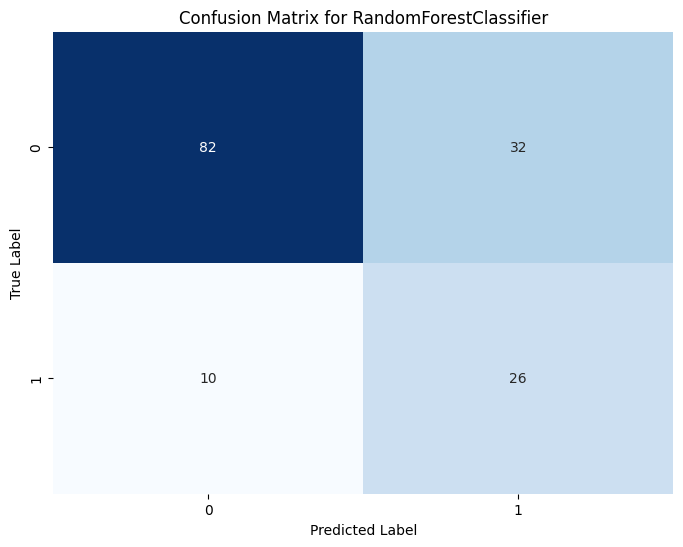

In [19]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model_pipeline.classes_, yticklabels=model_pipeline.classes_)
plt.title('Confusion Matrix for RandomForestClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted')
recall_w = recall_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Overall Precision (weighted): {precision_w:.4f}")
print(f"Overall Recall (weighted): {recall_w:.4f}")
print(f"Overall F1-Score (weighted): {f1_w:.4f}")

if y.nunique() == 2:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of positive class
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")

print("\nModel evaluation complete.")


Overall Accuracy: 0.7200
Overall Precision (weighted): 0.7850
Overall Recall (weighted): 0.7200
Overall F1-Score (weighted): 0.7378
ROC-AUC: 0.7663

Model evaluation complete.


In [21]:
# --- Step 8: Recommendation System Implementation ---
print("\n--- Step 8: Recommendation System Implementation ---")


recommendation_mapping = {
    0: 'No immediate action needed; maintain current health routine.',
    1: 'Recommendation: Consult with a healthcare professional for further evaluation/check-up.'
    # Based on a binary Class 0 or 1.
}


--- Step 8: Recommendation System Implementation ---


In [22]:
def generate_recommendations(patient_data_raw, trained_pipeline, rec_map):
    """
    Generates a personalized healthcare recommendation based on raw patient data.
    patient_data_raw: A Pandas DataFrame (single row) containing raw patient input.
                      Columns must match original features (Recency, Frequency, Monetary, Time).
    trained_pipeline: The fitted sklearn pipeline that preprocesses and predicts.
    rec_map: Dictionary mapping class IDs to human-readable recommendations.
    """
    prediction_class_id = trained_pipeline.predict(patient_data_raw)[0]
    recommendation = rec_map.get(prediction_class_id, "Unknown recommendation class. Please contact support.")
    return recommendation

# Example patient data for recommendation generation (using median values from original data)
example_patient_data = pd.DataFrame({
    'Recency': [data['Recency'].median()],
    'Frequency': [data['Frequency'].median()],
    'Monetary': [data['Monetary'].median()],
    'Time': [data['Time'].median()]
})

In [23]:
print(f"\nExample patient data for recommendation:\n{example_patient_data}")

recommendation = generate_recommendations(example_patient_data, model_pipeline, recommendation_mapping)
print(f"\nPersonalized Recommendation for the example patient: **{recommendation}**")

print("\nRecommendation system implementation (mock example) complete.")


# --- Step 9: Deployment  ---

try:
    joblib.dump(model_pipeline, 'recommendation_pipeline.joblib')
    print("Model pipeline saved successfully as 'recommendation_pipeline.joblib'.")
    # No need to save scaler separately, it's inside the pipeline.
except Exception as e:
    print(f"Error saving model pipeline: {e}")

print("\nDeployment conceptualization and model saving complete.")


Example patient data for recommendation:
   Recency  Frequency  Monetary  Time
0      7.0        4.0    1000.0  28.0

Personalized Recommendation for the example patient: **No immediate action needed; maintain current health routine.**

Recommendation system implementation (mock example) complete.
Model pipeline saved successfully as 'recommendation_pipeline.joblib'.

Deployment conceptualization and model saving complete.
